# WaveHoltz as a Helmholtz preconditioner — single and batched solves

The Helmholtz operator $A$ (with PML) is **indefinite and strongly non-normal**,
so unpreconditioned Krylov on $A v = f$ stalls. **WaveHoltz** reformulates it as

$$ (I - S)\,v = b, \qquad S v = \Pi[v],\quad b = \Pi_{-f}[0], $$

where $\Pi$ filters a one-period time-domain wave solve. The map $I - S$ has a
**clustered spectrum** $\{1 - \beta(\mu)\}$ with $|\beta| < 1$, so a few GMRES
iterations suffice — and the iteration count is essentially mesh/frequency
independent. The PML is *aligned by construction*: the time-domain ADE-PML
($e^{-\sigma\,dt}$) and the frequency-domain stretch ($1 + i\sigma/\omega$) read
the **same** $\sigma$ profile.

This notebook shows:
1. building a PML Helmholtz problem,
2. a single preconditioned solve and what `waveholtz_system` returns,
3. **batched** solves over many right-hand sides with `vmap` (`solve_batched`),
4. the advertised, bounded iteration count vs. direct GMRES.

In [1]:
import os, sys, time
import numpy as np
import jax
from jax import config
config.update("jax_enable_x64", True)   # WaveHoltz needs float64
import jax.numpy as jnp
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))  # project root, matching the other notebooks

from inverse_scattering_jax.src.helmholtz import (
    HelmholtzOperator, HelmholtzSolver, Domain, GMRESOptions,
)
from inverse_scattering_jax.src.waveholtz import WaveHoltzSolver, WaveHoltzOptions

print("jax", jax.__version__, "| devices:", jax.devices())

jax 0.9.2 | devices: [CpuDevice(id=0)]


## 1. Build a PML Helmholtz problem

`make_op` fixes the resolution at a chosen points-per-wavelength so the grid is
sensibly sized for the frequency. `gaussian` makes a localized point-source RHS;
we can place it anywhere to build a batch later.

In [2]:
def make_op(omega=8.0, ppw=18.0, box=2.0, npml=15, sigma_max=30.0):
    h = 2.0 * np.pi / (omega * ppw)
    nx_int = int(round(box / h))
    nx = ny = nx_int + 2 * npml
    dom = Domain(nx=nx, ny=ny, npml=npml, h=h)
    return HelmholtzOperator(domain=dom, omega=omega, sigma_max=sigma_max, mode='stencil')

def gaussian(op, width=0.10, cx=0.0, cy=0.0):
    x = (jnp.arange(op.nx) - op.nx / 2) * op.h
    y = (jnp.arange(op.ny) - op.ny / 2) * op.h
    X, Y = jnp.meshgrid(x, y, indexing='xy')
    g = jnp.exp(-((X - cx) ** 2 + (Y - cy) ** 2) / (2 * width ** 2))
    return g.flatten().astype(jnp.complex128)

op = make_op()
m_ext = jnp.ones((op.ny, op.nx))                 # homogeneous medium (m = 1)
print(f"grid {op.nx}x{op.ny} = {op.nx*op.ny} dof | omega={op.omega} | npml={op.npml} | h={op.h:.4f}")

grid 76x76 = 5776 dof | omega=8.0 | npml=15 | h=0.0436


## 2. A single preconditioned solve

`WaveHoltzSolver.solve` builds $(I-S)$ and $b$ internally and runs GMRES. The
`exponential` filter is the one for absorbing/PML problems; `gmres` is the
recommended outer solver (the exponential filter is not strictly contractive).

In [3]:
f = gaussian(op, cx=0.0, cy=0.0)

solver = WaveHoltzSolver(op=op, options=WaveHoltzOptions(
    filter='exponential', solver='gmres', n_periods=6, tol=1e-8, maxiter=400))

v, info = solver.solve(f, m_ext)
print("relative residual  ||(I - S) v - b|| / ||b|| =", float(info['residual']))

relative residual  ||(I - S) v - b|| / ||b|| = 2.718706770196912e-15


`waveholtz_system` exposes the preconditioned operator directly, so you can
feed it to any Krylov solver of your choice. It returns `(matvec, b)` with
`matvec(v) = v - S v`.

In [4]:
matvec, b = solver.waveholtz_system(f, m_ext)
print("||b|| =", float(jnp.linalg.norm(b)))
print("check ||(I - S) v - b|| / ||b|| =",
      float(jnp.linalg.norm(matvec(v) - b) / jnp.linalg.norm(b)))

||b|| = 0.19014525551883762
check ||(I - S) v - b|| / ||b|| = 2.718706770196912e-15


Compare against a direct frequency-domain solve on the physical interior
(the PML layer is excluded — the two formulations' absorbing fields differ there).
The residual above is solved to machine precision; the *interior* error is the
time- vs frequency-domain PML realization mismatch, which shrinks ~2nd order with
resolution (`ppw`) and with a longer filter window (`n_periods`). The phasor may
come out complex-conjugated relative to the FD sign convention, so we take the
better of $v$ and $\bar v$.

In [5]:
ref = HelmholtzSolver(op=op, gmres_options=GMRESOptions(tol=1e-9, maxiter=5000))
u_ref, _ = ref.solve(f, m_ext)

npml = op.npml
sl = (slice(npml, -npml), slice(npml, -npml))
A = v.reshape(op.ny, op.nx)[sl]
B = u_ref.reshape(op.ny, op.nx)[sl]
rel = min(float(jnp.linalg.norm(A - B) / jnp.linalg.norm(B)),
          float(jnp.linalg.norm(jnp.conj(A) - B) / jnp.linalg.norm(B)))
print(f"interior rel. error vs direct Helmholtz solve = {rel:.4f}")

interior rel. error vs direct Helmholtz solve = 0.0913


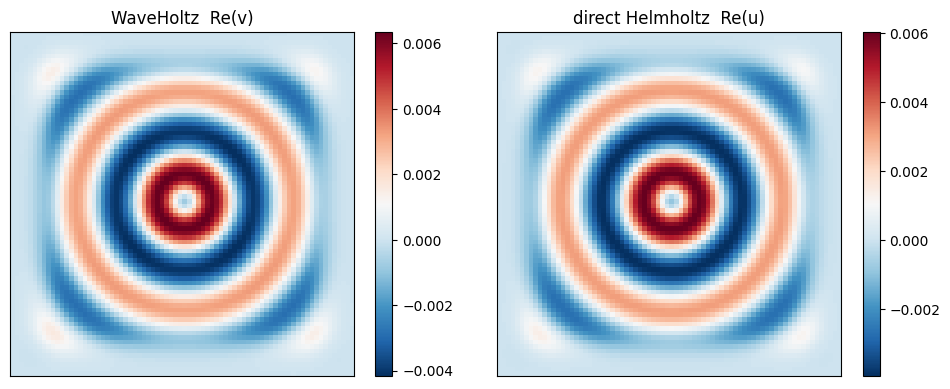

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, fld, ttl in [(axes[0], v, 'WaveHoltz  Re(v)'),
                     (axes[1], u_ref, 'direct Helmholtz  Re(u)')]:
    im = ax.imshow(np.real(np.asarray(fld)).reshape(op.ny, op.nx),
                   cmap='RdBu_r', origin='lower')
    ax.set_title(ttl); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 3. Batched solves over many RHS with `vmap`

The payoff of a matrix-free, time-stepping solver: **many right-hand sides at
once**. `solve_batched(F, m_ext)` `vmap`s the whole solve over the columns of
`F` (shape `(n_dof, n_rhs)`) and is JIT-compiled. Here we scatter five sources.

In [7]:
centers = [(0.0, 0.0), (0.45, -0.30), (-0.35, 0.25), (0.20, 0.45), (-0.40, -0.40)]
F = jnp.stack([gaussian(op, width=0.10, cx=cx, cy=cy) for cx, cy in centers], axis=1)
print("F shape (n_dof, n_rhs):", F.shape)

V = solver.solve_batched(F, m_ext)
print("V shape:", V.shape)

F shape (n_dof, n_rhs): (5776, 5)


V shape: (5776, 5)


**Correctness:** the batched result matches solving each column on its own,
to round-off.

In [8]:
for j in range(F.shape[1]):
    vj, _ = solver.solve(F[:, j], m_ext)
    rel = float(jnp.linalg.norm(V[:, j] - vj) / jnp.linalg.norm(vj))
    print(f"col {j}: batched vs single-solve rel diff = {rel:.1e}")

col 0: batched vs single-solve rel diff = 3.9e-16


col 1: batched vs single-solve rel diff = 3.3e-16


col 2: batched vs single-solve rel diff = 4.4e-16


col 3: batched vs single-solve rel diff = 7.6e-16


col 4: batched vs single-solve rel diff = 4.0e-16


**Throughput:** time the `vmap` batch against a Python loop. We warm up
first so we measure compute, not JIT tracing. (On CPU the gain is modest; the
`vmap` structure is what lets this scale on GPU/TPU.)

In [9]:
# Warm up / compile both paths.
solver.solve_batched(F, m_ext).block_until_ready()
solver.solve(F[:, 0], m_ext)[0].block_until_ready()

t0 = time.perf_counter()
Vb = solver.solve_batched(F, m_ext); Vb.block_until_ready()
t_batch = time.perf_counter() - t0

t0 = time.perf_counter()
loop = [solver.solve(F[:, j], m_ext)[0] for j in range(F.shape[1])]
jnp.stack(loop, axis=1).block_until_ready()
t_loop = time.perf_counter() - t0

print(f"loop over {F.shape[1]} RHS : {t_loop*1e3:7.1f} ms")
print(f"vmap solve_batched   : {t_batch*1e3:7.1f} ms   ({t_loop/t_batch:.2f}x)")

loop over 5 RHS :  7714.3 ms
vmap solve_batched   :  4294.1 ms   (1.80x)


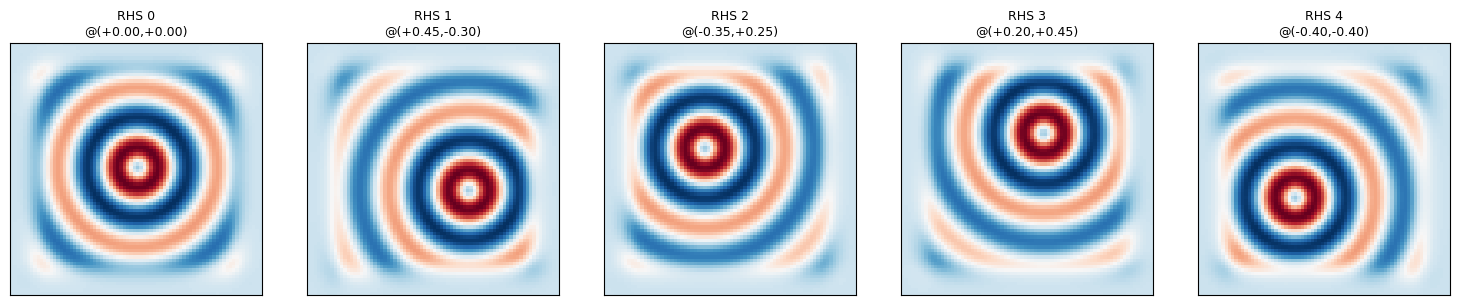

In [10]:
fig, axes = plt.subplots(1, len(centers), figsize=(3 * len(centers), 3))
for j, ax in enumerate(axes):
    im = ax.imshow(np.real(np.asarray(V[:, j])).reshape(op.ny, op.nx),
                   cmap='RdBu_r', origin='lower')
    ax.set_title(f"RHS {j}\n@({centers[j][0]:+.2f},{centers[j][1]:+.2f})", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 4. The advertised step count

The reason to bother: the WaveHoltz iteration count is **bounded and ~independent
of frequency/mesh**, while unpreconditioned GMRES on $A$ climbs steadily. We use
the benchmark harness to count exact GMRES iterations for both.

In [11]:
from inverse_scattering_jax.benchmarks.benchmark_waveholtz import measure

print(f"{'omega':>6} {'dof':>7} {'direct GMRES on A':>18} {'WaveHoltz-GMRES (I-S)':>22}")
for w in (4.0, 8.0, 12.0):
    r = measure(w, ppw=10.0, box=2.0, do_fixed_point=False)
    print(f"{w:6.1f} {r.n:7d} {r.its_direct:18d} {r.its_wh:22d}")

 omega     dof  direct GMRES on A  WaveHoltz-GMRES (I-S)


   4.0    1849                126                      6


   8.0    3025                162                      6


  12.0    4624                185                      7


**Direct** GMRES grows with $\omega$; **WaveHoltz** stays at a handful of
iterations. See `inverse_scattering_jax/benchmarks/benchmark_waveholtz.py` for
the full frequency-scaling and mesh-independence study.

### Choosing the filter

| problem | `filter` | `use_pml` | outer `solver` | gives |
|---|---|---|---|---|
| absorbing / PML Helmholtz (complex) | `'exponential'` | `True` | `'gmres'` | complex phasor |
| real, energy-conserving (no PML) | `'cosine'` | `False` | `'gmres'` or `'fixed_point'` | real field |

The `exponential` phasor filter contracts **damped** (PML) modes; the original
AGR2020 `cosine` filter contracts **real** modes and recovers the real solution
of the energy-conserving problem.